In [1]:
#new project hehe

In [2]:
import opendatasets as od
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
dataset = 'https://www.kaggle.com/datasets/siddharthm1698/coursera-course-dataset'

In [4]:
def data_from_kaggle(dataset):
    """
    Download a Kaggle dataset using opendatasets and return the loaded DataFrame. Works with only one csv
    
    Args:
        dataset: Kaggle dataset URL.
    
    Returns:
        df (pd.DataFrame): CSV file found in the dataset folder, converted to pd.DataFrame
    """
    data_dir =  od.download(dataset)
    if data_dir is None:
        # Extract folder name from URL
        folder_name = dataset.split('/')[-1]
        data_dir = f'./{folder_name}'
    file = os.listdir(data_dir)
    csv_path = os.path.join(data_dir, file[0])
    df = pd.read_csv(csv_path)
    return df
    

In [5]:
cours = data_from_kaggle(dataset) #you'll need your Kaggle credentials (username and API key) to use that

Skipping, found downloaded files in ".\coursera-course-dataset" (use force=True to force download)


In [6]:
cours.head()

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [7]:
cours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                891 non-null    int64  
 1   course_title              891 non-null    object 
 2   course_organization       891 non-null    object 
 3   course_Certificate_type   891 non-null    object 
 4   course_rating             891 non-null    float64
 5   course_difficulty         891 non-null    object 
 6   course_students_enrolled  891 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 48.9+ KB


In [8]:
#CLEANING

In [9]:
#drop unnamed column, students enrolled to int in thousands, course diffuculty maybe

In [10]:
cours_cleaned = cours.drop(columns = ["Unnamed: 0"])

In [11]:
cours_cleaned.head()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [12]:
cours_cleaned = cours_cleaned.drop_duplicates()

In [13]:
cours_cleaned.shape

(891, 6)

In [14]:
cours.shape

(891, 7)

In [15]:
#no duplicates

In [16]:
#looking at nan values

In [17]:
cours_cleaned.isnull().sum()

course_title                0
course_organization         0
course_Certificate_type     0
course_rating               0
course_difficulty           0
course_students_enrolled    0
dtype: int64

In [18]:
cours_cleaned = cours_cleaned.rename( columns = {
    'course_title':'Title',
    'course_organization': 'Organization',
    'course_Certificate_type': 'Certificate', 
    'course_rating' : 'Rating', 
    'course_difficulty' : 'Difficulty', 
    'course_students_enrolled': 'Students(thousands)' 
}
                                    )

In [19]:
cours_cleaned.head()

,Title,Organization,Certificate,Rating,Difficulty,Students(thousands)
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [20]:
cours_cleaned['Students(thousands)'] = cours_cleaned['Students(thousands)'].str.replace('k', '').str.strip()

In [21]:
cours_cleaned['Students(thousands)'].unique()  

array(['5.3', '17', '130', '91', '320', '39', '350', '2.4', '61', '12',
       '4', '13', '11', '27', '110', '6.6', '540', '22', '2.9', '80',
       '9.9', '23', '9.2', '78', '190', '35', '29', '14', '21', '94',
       '69', '40', '220', '150', '18', '270', '7.9', '30', '36', '20',
       '8.1', '120', '71', '63', '42', '480', '97', '200', '180', '4.2',
       '310', '3.9', '79', '31', '15', '10', '66', '33', '56', '7.3',
       '9.7', '210', '28', '6.5', '55', '2.3', '8.8', '88', '1.9', '68',
       '1.6', '9.5', '57', '26', '84', '95', '5.8', '24', '67', '280',
       '38', '77', '510', '89', '48', '160', '32', '340', '82', '790',
       '19', '51', '4.8', '37', '43', '6.4', '49', '240', '46', '7.8',
       '75', '81', '140', '5.5', '99', '100', '3', '830', '740', '60',
       '96', '690', '44', '4.5', '8.2', '16', '300', '8', '41', '54', '9',
       '380', '58', '5.6', '7.1', '83', '3.4', '1.5', '230', '760', '86',
       '45', '7.2', '1.8', '4.1', '76', '490', '170', '260', '65', '

In [22]:
#we can also see that there are some millions as well, so we have to change that to thousands and then delete m
#One million is 1000 thousands, so we

In [23]:
cours_cleaned[cours_cleaned['Students(thousands)'].str.contains('m', case=False)]

,Title,Organization,Certificate,Rating,Difficulty,Students(thousands)
564,Machine Learning,Stanford University,COURSE,4.9,Mixed,3.2m
674,Programming for Everybody (Getting Started wit...,University of Michigan,COURSE,4.8,Mixed,1.3m
688,Python for Everybody,University of Michigan,SPECIALIZATION,4.8,Beginner,1.5m
815,The Science of Well-Being,Yale University,COURSE,4.9,Mixed,2.5m


In [24]:
#there are only 4 courses and each of them has a decimal value, so since each million contains 1000 thousands, and since, for
#example 3.2m = 3200 thousands, what we'll do is just replace m with 00 and delete a period

In [25]:
def m_to_k(x):
    x = str(x)

    if x.endswith('m'):              
        return float(x[:-1]) * 1000 
    else:
        return float(x)   

In [26]:
cours_cleaned['Students(thousands)'] = cours_cleaned['Students(thousands)'].apply(m_to_k)

In [27]:
np.set_printoptions(suppress=True) #suppressing scientific notation 

In [28]:
#sanity check let's see if only right values were affected
cours_cleaned['Students(thousands)'] .unique()

array([   5.3,   17. ,  130. ,   91. ,  320. ,   39. ,  350. ,    2.4,
         61. ,   12. ,    4. ,   13. ,   11. ,   27. ,  110. ,    6.6,
        540. ,   22. ,    2.9,   80. ,    9.9,   23. ,    9.2,   78. ,
        190. ,   35. ,   29. ,   14. ,   21. ,   94. ,   69. ,   40. ,
        220. ,  150. ,   18. ,  270. ,    7.9,   30. ,   36. ,   20. ,
          8.1,  120. ,   71. ,   63. ,   42. ,  480. ,   97. ,  200. ,
        180. ,    4.2,  310. ,    3.9,   79. ,   31. ,   15. ,   10. ,
         66. ,   33. ,   56. ,    7.3,    9.7,  210. ,   28. ,    6.5,
         55. ,    2.3,    8.8,   88. ,    1.9,   68. ,    1.6,    9.5,
         57. ,   26. ,   84. ,   95. ,    5.8,   24. ,   67. ,  280. ,
         38. ,   77. ,  510. ,   89. ,   48. ,  160. ,   32. ,  340. ,
         82. ,  790. ,   19. ,   51. ,    4.8,   37. ,   43. ,    6.4,
         49. ,  240. ,   46. ,    7.8,   75. ,   81. ,  140. ,    5.5,
         99. ,  100. ,    3. ,  830. ,  740. ,   60. ,   96. ,  690. ,
      

In [29]:
cours_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                891 non-null    object 
 1   Organization         891 non-null    object 
 2   Certificate          891 non-null    object 
 3   Rating               891 non-null    float64
 4   Difficulty           891 non-null    object 
 5   Students(thousands)  891 non-null    float64
dtypes: float64(2), object(4)
memory usage: 48.7+ KB


In [30]:
#finished with data prepping(still not clean, just works) let's answer some questionsss

In [31]:
#ANSWERING QUESTIONS IN DATASET

In [32]:
#how many types of certificates, how many organizations, possibly correlation between difficulty and nb of students

In [33]:
df = cours_cleaned.copy()

In [34]:
#how many courses in dataset

In [35]:
print(f"There are {len(df)} courses in this dataset")

There are 891 courses in this dataset


In [ ]:
#Certificaton exploration

In [36]:
#What are different certification types present in the dataset

In [37]:
res = ', '.join(df['Certificate'].unique())

In [38]:
print(f"There are {len(df['Certificate'].unique())} certification types.\nHere is a list of all of them: {res.lower()}")

There are 3 certification types.
Here is a list of all of them: specialization, course, professional certificate


In [39]:
#how many courses per certification type

Text(0, 0.5, 'Number of Courses')

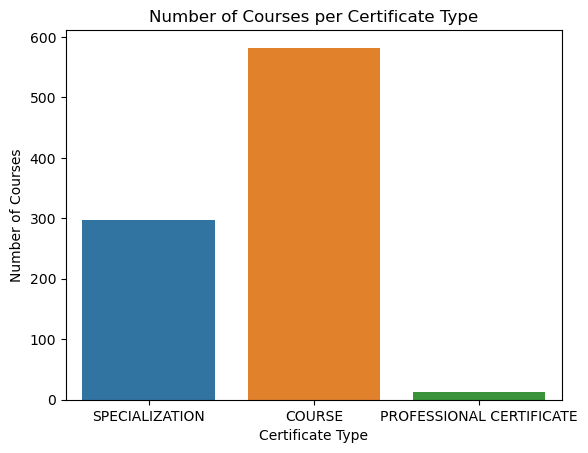

In [41]:
sns.countplot(data=df, x='Certificate')
plt.title("Number of Courses per Certificate Type")
plt.xlabel("Certificate Type")
plt.ylabel("Number of Courses")

In [ ]:
#Most popular  certificate (by number of courses ) is just Course, that is followed by
#specialization and professional certificate

In [ ]:
#Is it the same with popularity by number of students enrolled?

Text(0, 0.5, 'Students(thousands)')

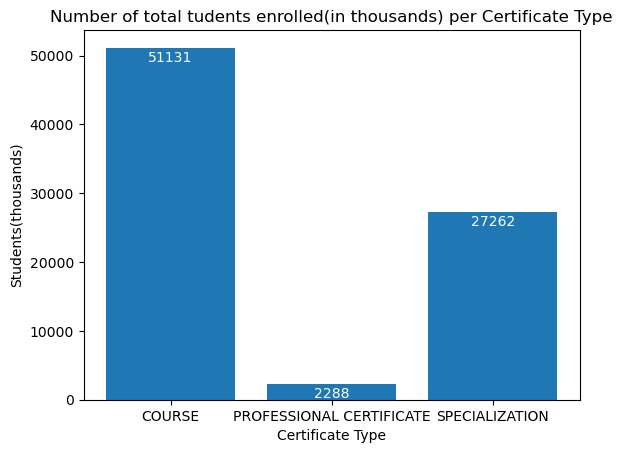

In [91]:
grouped = df.groupby('Certificate')['Students(thousands)'].sum()
bars = plt.bar(grouped.index, grouped.values)
for i, v in enumerate(grouped.values):
    plt.text(i, v - 2000, str(int(v)), ha='center', fontsize=10, color = "white")
plt.title("Number of total tudents enrolled(in thousands) per Certificate Type")
plt.xlabel("Certificate Type")
plt.ylabel("Students(thousands)")

<Axes: xlabel='Difficulty', ylabel='Certificate'>

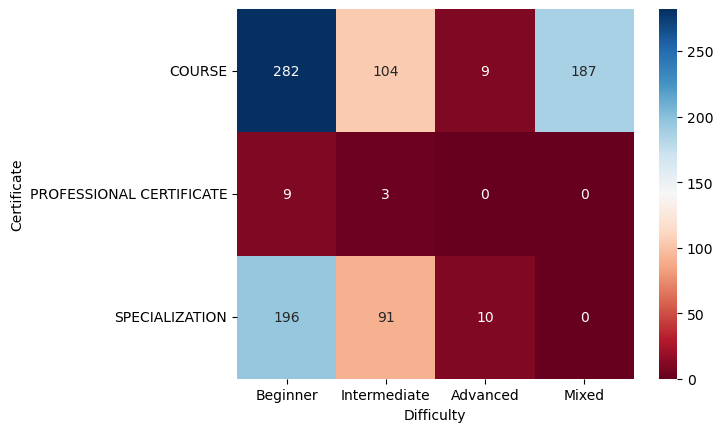

In [59]:
c_d = pd.crosstab(df['Certificate'], df['Difficulty'])
desired_order = ['Beginner', 'Intermediate', 'Advanced', 'Mixed']
c_d = c_d[desired_order]
sns.heatmap(c_d, annot=True, fmt="d", cmap="RdBu")

In [60]:
#Аналіз ось цього. Most popular stuff is beginner course and it drastically declines with збільшленням важкості курсу. 
#

In [42]:
#how many different organizations there are

In [43]:
print(f"There are {len(df['Organization'].unique())} organizators on coursera")

There are 154 organizators on coursera


In [134]:
max_cours = df['Organization'].value_counts()
max_cours = max_cours[:10]

print(f'Top organizations by number of courses :')
for i in range(10):
    print(f'{i+1}. {max_cours.index[i]} with {max_cours.iloc[i]} courses.')


Top organizations by number of courses :
1. University of Pennsylvania with 59 courses.
2. University of Michigan with 41 courses.
3. Google Cloud with 34 courses.
4. Johns Hopkins University with 28 courses.
5. Duke University with 28 courses.
6. University of California, Irvine with 27 courses.
7. IBM with 22 courses.
8. University of Illinois at Urbana-Champaign with 22 courses.
9. University of California, Davis with 21 courses.
10. University of Colorado Boulder with 19 courses.


(15.0, 60.0)

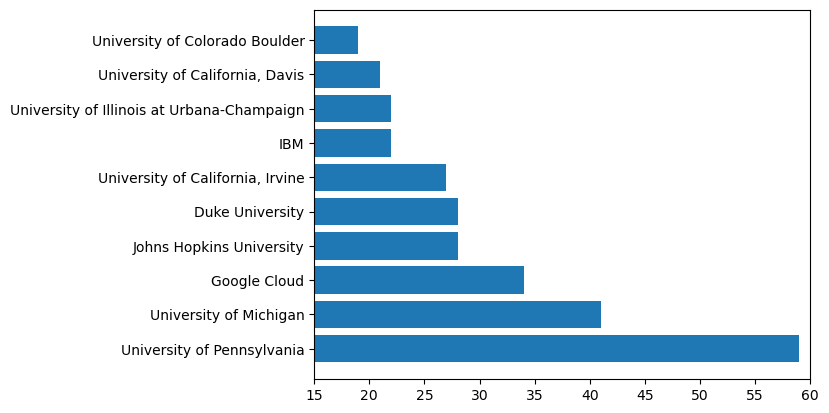

In [135]:
bars = plt.barh(max_cours.index, max_cours.values)
plt.xlim(15, 60)

In [98]:
max_rate = df.groupby('Organization')['Rating'].mean().sort_values(ascending = False)

max_rate
 #many organizations have only one course that's why it's quite easy to maintain high score. Let's look through our top 10 by 
    #quantity

Organization
Hebrew University of Jerusalem                 4.900
Nanyang Technological University, Singapore    4.900
Universidade Estadual de Campinas              4.900
Crece con Google                               4.900
London Business School                         4.900
                                               ...  
Luther College at the University of Regina     4.400
Unity                                          4.350
New York Institute of Finance                  4.300
Tsinghua University                            4.300
The State University of New York               4.275
Name: Rating, Length: 154, dtype: float64

In [136]:
max_rate_top = df[df['Organization'].isin(max_cours.index)].groupby('Organization')['Rating'].mean().sort_values(ascending = False)
max_rate_top

Organization
University of Michigan                        4.729268
University of Pennsylvania                    4.696610
University of Colorado Boulder                4.668421
Duke University                               4.664286
Johns Hopkins University                      4.660714
University of Illinois at Urbana-Champaign    4.654545
University of California, Davis               4.619048
IBM                                           4.613636
University of California, Irvine              4.596296
Google Cloud                                  4.582353
Name: Rating, dtype: float64

(4.55, 4.75)

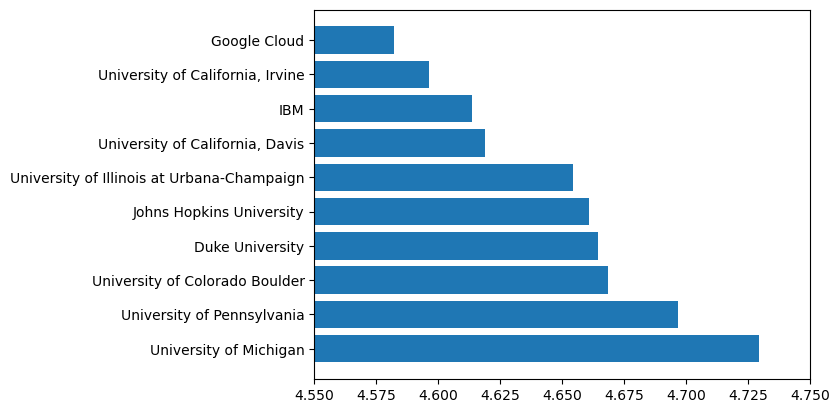

In [137]:
bars = plt.barh(max_rate_top.index, max_rate_top.values)
plt.xlim(4.55, 4.75)

In [138]:
#how many students are enrolled in each of those organisations

In [146]:
max_stud

Organization
University of Michigan                        7437.7
University of Pennsylvania                    5501.3
University of California, Irvine              4326.0
Johns Hopkins University                      4298.9
Duke University                               3967.6
IBM                                           2956.4
Google Cloud                                  2604.3
University of Illinois at Urbana-Champaign    1679.0
University of California, Davis               1278.7
University of Colorado Boulder                 614.9
Name: Students(thousands), dtype: float64

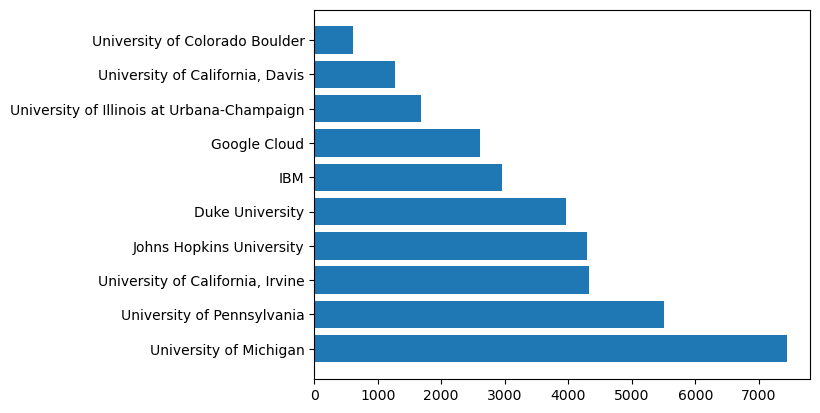

In [145]:
max_stud = df[df['Organization'].isin(max_cours.index)].groupby('Organization')['Students(thousands)'].sum().sort_values(ascending = False)
bars = plt.barh(max_stud.index, max_stud.values)

In [150]:
df_all = pd.DataFrame({
    "Students": max_stud,
    "Rating": max_rate_top,
    "Courses": max_cours
})

In [151]:
df_all

,Students,Rating,Courses
Duke University,3967.6,4.664286,28
Google Cloud,2604.3,4.582353,34
IBM,2956.4,4.613636,22
Johns Hopkins University,4298.9,4.660714,28
"University of California, Davis",1278.7,4.619048,21
"University of California, Irvine",4326.0,4.596296,27
University of Colorado Boulder,614.9,4.668421,19
University of Illinois at Urbana-Champaign,1679.0,4.654545,22
University of Michigan,7437.7,4.729268,41
University of Pennsylvania,5501.3,4.696610,59


In [ ]:
#sanity check to make sure dataframe is correct
example = "University of Illinois at Urbana-Champaign"
df[df['Organization'] == example]['Rating'].mean()
df[df['Organization'] == example]['Students(thousands)'].sum()
len(df[df['Organization'] == ecample])

In [165]:
df_rank = df_all.rank(ascending=False, method="first")
df_rank

,Students,Rating,Courses
Duke University,5.0,4.0,4.0
Google Cloud,7.0,10.0,3.0
IBM,6.0,8.0,7.0
Johns Hopkins University,4.0,5.0,5.0
"University of California, Davis",9.0,7.0,9.0
"University of California, Irvine",3.0,9.0,6.0
University of Colorado Boulder,10.0,3.0,10.0
University of Illinois at Urbana-Champaign,8.0,6.0,8.0
University of Michigan,1.0,1.0,2.0
University of Pennsylvania,2.0,2.0,1.0


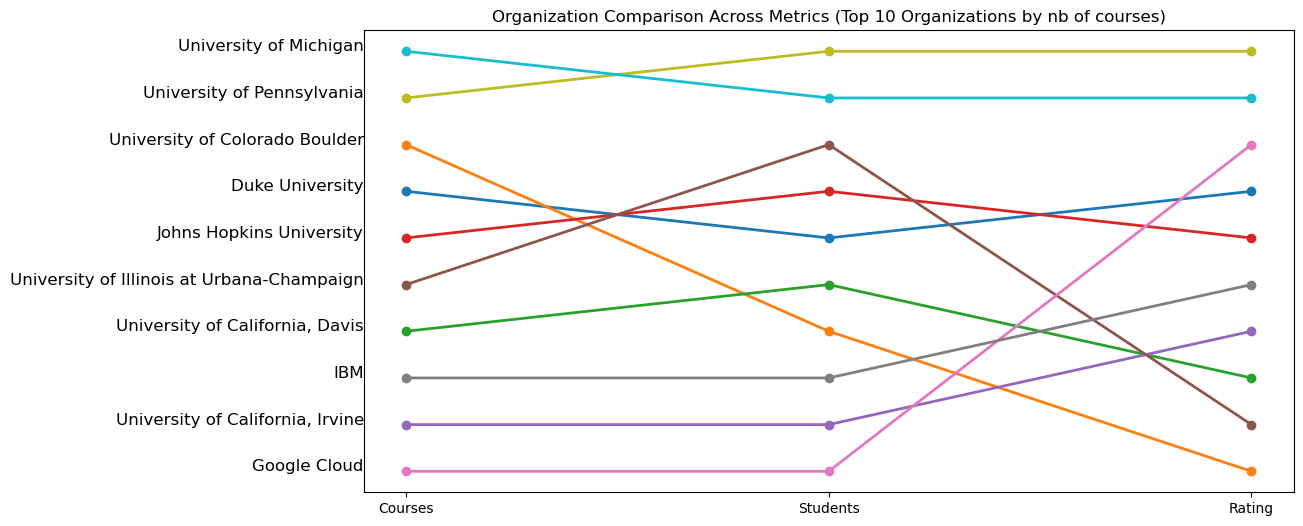

In [187]:
metrics = ["Courses", "Students", "Rating"]

plt.figure(figsize=(12,6))

for org in df_rank.index:
    plt.plot(metrics, df_rank.loc[org, metrics], marker="o", linewidth=2)

# Highest rank (1) at top
ax = plt.gca()
ax.invert_yaxis()
ax.get_yaxis().set_visible(False)

plt.title("Organization Comparison Across Metrics (Top 10 Organizations by nb of courses)")
plt.ylabel("Rank")
plt.xticks(metrics)
for org in df_rank.index:
    plt.text(
        x=-0.1,
        y=df_rank.loc[org, metrics][-1],
        s=org,
        fontsize=12,
        ha = 'right'
    )
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [ ]:
#аналіз ось цього

22

In [45]:
#top courses by rating,, correlation between nb of courses per organization and rating.
#Correlation of rating and nb of students, total of students per top schools, idk what else

In [61]:
#RATING

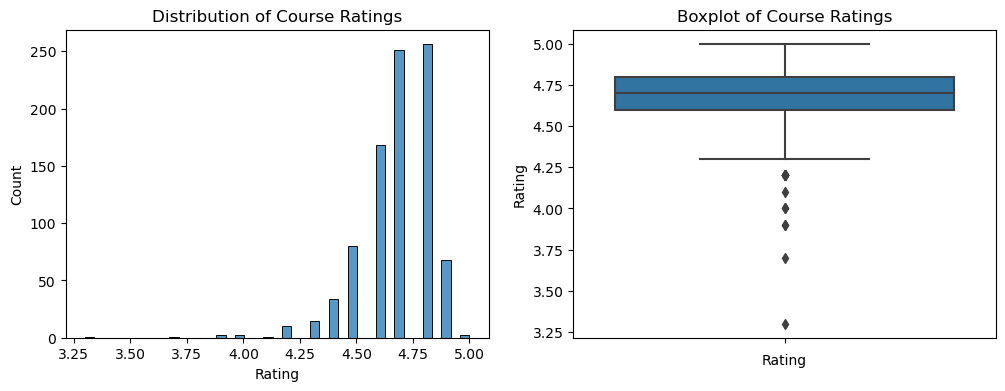

In [75]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
sns.histplot(data = df['Rating'])
plt.title("Distribution of Course Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Rating'])
plt.title("Boxplot of Course Ratings")
plt.xlabel("Rating")
plt.show()

In [76]:
#analysis

In [48]:
df[['Rating', 'Students(thousands)']].corr() #surprisingly not a big correlation between rating ans students enrolled

,Rating,Students(thousands)
Rating,1.00000,0.07109
Students(thousands),0.07109,1.00000


<Axes: xlabel='Rating', ylabel='Students(thousands)'>

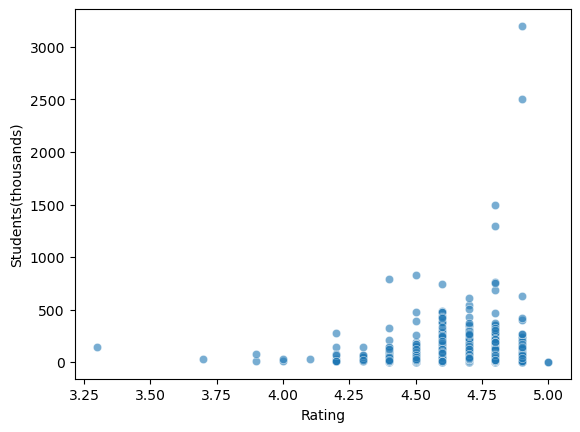

In [188]:
sns.scatterplot(
    data=df,
    x="Rating",
    y="Students(thousands)",
    alpha=0.6
)

In [ ]:
#Let's find if there is a relation between course difficulty and rating

In [52]:
df.groupby('Difficulty')['Rating'].mean()

Difficulty
Advanced        4.600000
Beginner        4.680903
Intermediate    4.646465
Mixed           4.708556
Name: Rating, dtype: float64

<Figure size 700x500 with 0 Axes>

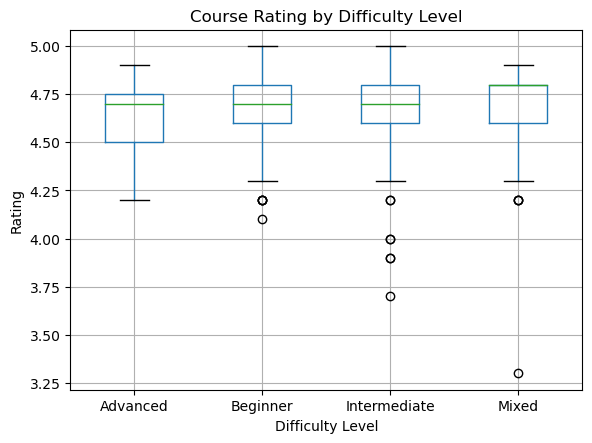

In [54]:
plt.figure(figsize=(7,5))
df.boxplot(column='Rating', by='Difficulty')
plt.title("Course Rating by Difficulty Level")
plt.suptitle("")
plt.xlabel("Difficulty Level")
plt.ylabel("Rating")
plt.show()

In [ ]:
# no real difference ir is approximately the same #CHANGE NICELY FROM ADVANCED TO BEGINNER